### <font color=skyblue>Classify the AT&T face image data using original face images and Eigenfaces</font>

Multiple classifiers will be used to classify the AT&T face image data, including Multinomial Logistic Regression (MLR), Support Vector Machines (SVM), and Artificial Neural Networks (ANN). The classification will be performed using both the original face images and the Eigenfaces derived from PCA.

利用 Eigenfaces 進行人臉分類的準確說法是，將原始人臉影像資料投影到由 Eigenfaces 組成的 face space (feace space) 中，取得投射係數（即 Z 向量）來進行分類。Z 向量的維度通常比原始影像的維度低很多，因此可以減少計算量並提高分類器的效能。這種方法既可以捕捉人臉的主要特徵，並且在降低維度的同時保留重要資訊，也有可能提高分類的準確性。

<hr>

<font color=yellow>Load the AT&T face image data and preprocess it for classification</font>

可以加入標準化

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('data/face_data.csv')
n_persons = df['target'].nunique() 
X = np.array(df.drop('target', axis=1)) # 400 x 4096
y = np.array(df['target'])

# split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)


<font color=yellow>Multinomial Logistic Regression (MLR)</font>

- Try different solvers for MLR, including 'lbfgs', 'liblinear', and 'newton-cg'. The solver can be specified in the LogisticRegression constructor.
- Try <u>LogisticRegressionCV</u> for automatic hyperparameter tuning. The LogisticRegressionCV class can be used to perform cross-validation and select the best hyperparameters (C and l1_ratio) for the model.

In [2]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score, classification_report

opts = dict(C=1.0, l1_ratio=0.0, tol = 1e-4, max_iter = int(1e6), verbose=1)
solver = 'lbfgs'  # 'lbfgs' is the default
# solver = 'liblinear'
# solver = 'newton-cg'
# clf_original = LogisticRegression(solver = 'lbfgs', tol = 1e-6, max_iter = int(1e6), verbose=True)
clf_MLR_original = LogisticRegression(solver = solver, **opts)
clf_MLR_original.fit(X_train, y_train) # input data must be (n_samples x n_features)
y_pred = clf_MLR_original.predict(X_test)
# print training score
print(f"Training score = {accuracy_score(y_train, clf_MLR_original.predict(X_train)):.2%}\n")
# print testing score
print(f"Testing score = {accuracy_score(y_test, y_pred):.2%}\n")
print(f"Testing score = {clf_MLR_original.score(X_test, y_test):.2%}\n")
print(classification_report(y_test, y_pred))

c:\Users\ccw\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1172: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


Training score = 100.00%

Testing score = 95.00%

Testing score = 95.00%

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         2
           3       1.00      0.50      0.67         6
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         5
           7       1.00      0.80      0.89         5
           8       1.00      1.00      1.00         4
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         4
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       0.50      1.00      0.67         1
          15       1.00      1.00      1.00         2
       

c:\Users\ccw\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\ccw\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\ccw\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(resu

<font color=yellow>Support Vector Machines (SVM)</font>

- Try different kernels for SVM, including 'linear', 'poly', 'rbf', and 'sigmoid'. The kernel can be specified in the SVC constructor. Be sure to adjust the hyperparameters (e.g., degree for 'poly', gamma for 'rbf') accordingly.
- Try different values for the regularization parameter C in SVM. A smaller C value leads to a larger margin, while a larger C value leads to a smaller margin.

In [3]:
from sklearn.svm import SVC, LinearSVC

C = 1  # SVM regularization parameter
opts = dict(C = C, decision_function_shape = 'ovr', \
            tol = 1e-4, max_iter = int(1e6))
kernel = 'linear'  # 'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'
clf_svm_original = SVC(kernel = kernel, **opts) 
# clf_svm_original = SVC(kernel="rbf", gamma=0.2, **opts)
# clf_svm_original = SVC(kernel="poly", degree=3, gamma="auto", **opts)
# clf_svm_original = LinearSVC(**opts) # one vs the rest
clf_svm_original.fit(X_train, y_train) 
predictions = clf_svm_original.predict(X_test)
print(classification_report(y_test, predictions)) 

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         2
           3       1.00      0.33      0.50         6
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         5
           7       1.00      0.80      0.89         5
           8       1.00      1.00      1.00         4
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         4
          11       1.00      1.00      1.00         2
          12       0.50      1.00      0.67         2
          13       1.00      1.00      1.00         2
          14       0.50      1.00      0.67         1
          15       1.00      1.00      1.00         2
          16       1.00      1.00      1.00         5
          17       1.00    

<font color=yellow>Artificial Neural Networks (ANN)</font>

- Try different architectures for the ANN, including varying the number of hidden layers and the number of neurons in each layer. 
- Try different activation functions for the hidden layers, such as 'relu', 'tanh', and 'logistic'. 
- Try different solvers for training the ANN, including 'sgd', 'adam', and 'lbfgs'.

Iteration 1, loss = 3.71598087
Iteration 2, loss = 3.70885783
Iteration 3, loss = 3.70528777
Iteration 4, loss = 3.70236759
Iteration 5, loss = 3.70082703
Iteration 6, loss = 3.69798529
Iteration 7, loss = 3.69541521
Iteration 8, loss = 3.69300062
Iteration 9, loss = 3.69069377
Iteration 10, loss = 3.68844484
Iteration 11, loss = 3.68637029
Iteration 12, loss = 3.68469612
Iteration 13, loss = 3.68297427
Iteration 14, loss = 3.68088352
Iteration 15, loss = 3.67860486
Iteration 16, loss = 3.67677991
Iteration 17, loss = 3.67524739
Iteration 18, loss = 3.67323990
Iteration 19, loss = 3.67178591
Iteration 20, loss = 3.66973910
Iteration 21, loss = 3.66816579
Iteration 22, loss = 3.66734086
Iteration 23, loss = 3.66525947
Iteration 24, loss = 3.66397419
Iteration 25, loss = 3.66287861
Iteration 26, loss = 3.66115585
Iteration 27, loss = 3.65928105
Iteration 28, loss = 3.65822601
Iteration 29, loss = 3.65694793
Iteration 30, loss = 3.65483723
Iteration 31, loss = 3.65400940
Iteration 32, los

c:\Users\ccw\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\ccw\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\ccw\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg

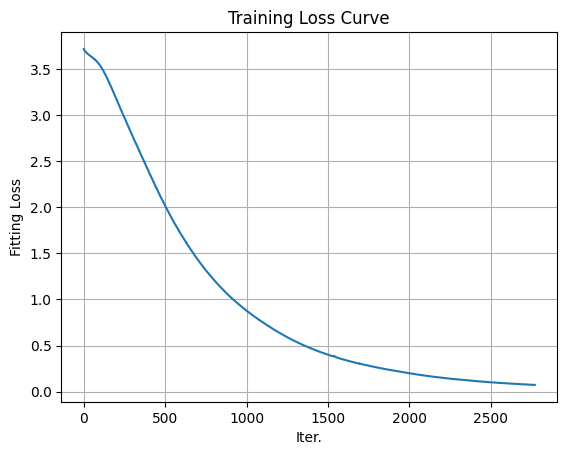

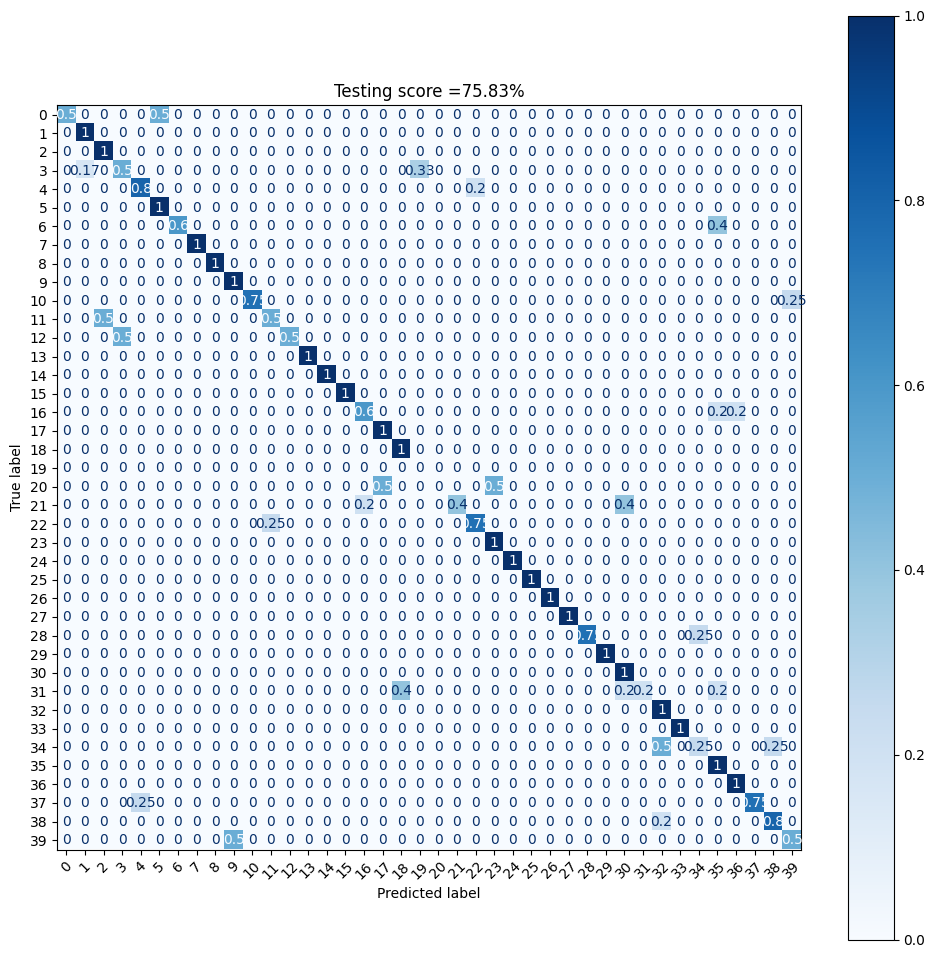

In [ ]:
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report



hidden_layers = (50,) # one hidden layer
activation = 'logistic' # the default
opts = dict(hidden_layer_sizes = hidden_layers, verbose = True, \
        activation = activation, tol = 1e-4, max_iter = int(1e6))
# solver = 'sgd' # not efficient, need more tuning
# solver = 'lbfgs' # not suitable here
solver = 'adam' # default solver
clf_MLP_original = MLPClassifier(solver = solver, **opts) 
clf_MLP_original.fit(X_train, y_train)
predictions = clf_MLP_original.predict(X_test)
# print("accuracy for tested data: {:.2f}%".format(100*np.mean(y_test_hat == y_test)))
print("accuracy for test data: {:.2f}%".format(100*clf_MLP_original.score(X_test, y_test)))
print(classification_report(y_test, predictions))
plt.plot(clf_MLP_original.loss_curve_)
plt.grid(True)
plt.title('Training Loss Curve')
plt.xlabel('Iter.')
plt.ylabel('Fitting Loss')
plt.show()

# Confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(12,12))
# Confusion matrix
title = 'Testing score ={:.2f}%'.format(100*clf_MLP_original.score(X_test, y_test))
disp = ConfusionMatrixDisplay.from_estimator(
        clf_MLP_original,
        X_test,
        y_test,
        xticks_rotation=45, #'vertical',
        # display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize='true',
        ax = ax
    )
disp.ax_.set_title(title)
plt.show() 

<font color=yellow>Cross-validation and hyperparameter tuning</font>

Use cross-validation to evaluate the performance of each classifier and select the best hyperparameters. The cross_val_score function from scikit-learn can be used to perform k-fold cross-validation and obtain the average accuracy score for each classifier.

In [6]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

para = {'kernel':('linear','rbf','poly','sigmoid'), \
        'gamma':('scale','auto'), \
        'decision_function_shape':('ovo','ovr')}
svc = SVC(tol = 1e-4, max_iter = int(1e6))
clf = GridSearchCV(svc, para, cv = 5)   # default: 5-fold
clf.fit(X_train, y_train)
# clf.cv_results_
print(f"# of folds: {clf.n_splits_}")
print(f"Mean cross-validated score of the best_estimator: {clf.best_score_:.2%}")
print(f"best combination: {clf.best_params_}", end = "\n\n")

c:\Users\ccw\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


# of folds: 5
Mean cross-validated score of the best_estimator: 91.79%
best combination: {'decision_function_shape': 'ovo', 'gamma': 'scale', 'kernel': 'linear'}



<font color=yellow>Use Eigenfaces</font>

- Use the PCA implementation from scikit-learn to compute the Eigenfaces from the original face images.
- Do PCA on the original face images to obtain the Eigenfaces. 
- Try different numbers of principal components for PCA to see how it affects the classification performance. 
- Repeat the classification process using the principal component scores (Z) as input features for MLR, SVM, and ANN. Compare the results with those obtained using the original face images.